In [1]:
import pandas as pd

df = pd.read_csv("results.csv")
df.shape

/var/folders/g1/xlgtdxyd3qs5145x8p7s4dy00000gp/T/ipykernel_48111/4167281295.py:3: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("results.csv")


(49191, 172)

In [2]:
df = pd.read_csv("results.csv", low_memory=False)
df.shape

(49191, 172)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 176.2 MB


In [4]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [5]:
cols = ["MainBranch", "Age", "EdLevel", "Employment", "WorkExp", 
        "DevType", "Country", "Currency", "ConvertedCompYearly", 
        "RemoteWork", "OrgSize", "JobSat"]

df_jobs = df[cols]
df_jobs.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,DevType,Country,Currency,ConvertedCompYearly,RemoteWork,OrgSize,JobSat
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,"Developer, mobile",Ukraine,EUR European Euro,61256.0,Remote,20 to 99 employees,10.0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,"Developer, back-end",Netherlands,EUR European Euro,104413.0,"Hybrid (some in-person, leans heavy to flexibi...",500 to 999 employees,9.0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,"Developer, front-end",Ukraine,UAH Ukrainian hryvnia,53061.0,NaN,NaN,8.0
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,"Developer, back-end",Ukraine,EUR European Euro,36197.0,Remote,"10,000 or more employees",6.0
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,Engineering manager,Ukraine,USD United States dollar,60000.0,NaN,NaN,7.0


In [6]:
df_jobs.isnull().sum()

MainBranch                 0
Age                        0
EdLevel                 1042
Employment               852
WorkExp                 6298
DevType                 5511
Country                13754
Currency               13754
ConvertedCompYearly    25244
RemoteWork             15411
OrgSize                15013
JobSat                 22521
dtype: int64

In [7]:
df_jobs.groupby("Employment")["ConvertedCompYearly"].apply(lambda x: x.isnull().mean())

Employment
Employed                                                0.422222
I prefer not to say                                     0.889961
Independent contractor, freelancer, or self-employed    0.545319
Not employed                                            0.773687
Retired                                                 0.812147
Student                                                 0.841238
Name: ConvertedCompYearly, dtype: float64

In [8]:
df_salary = df_jobs[(df_jobs["Employment"] == "Employed") & (df_jobs["ConvertedCompYearly"].notnull())]
df_salary.shape

(19500, 12)

In [9]:
df_salary["ConvertedCompYearly"].describe()

count    1.950000e+04
mean     1.025096e+05
std      3.440871e+05
min      1.000000e+00
25%      4.385400e+04
50%      7.889000e+04
75%      1.243732e+05
max      3.355272e+07
Name: ConvertedCompYearly, dtype: float64

In [10]:
df_salary_clean = df_salary[(df_salary["ConvertedCompYearly"] >= 10000) & 
                              (df_salary["ConvertedCompYearly"] <= 500000)]

In [11]:
df_salary_clean["ConvertedCompYearly"].describe()

count     17679.000000
mean     100249.876746
std       69527.469107
min       10000.000000
25%       52207.000000
50%       83792.000000
75%      130000.000000
max      500000.000000
Name: ConvertedCompYearly, dtype: float64

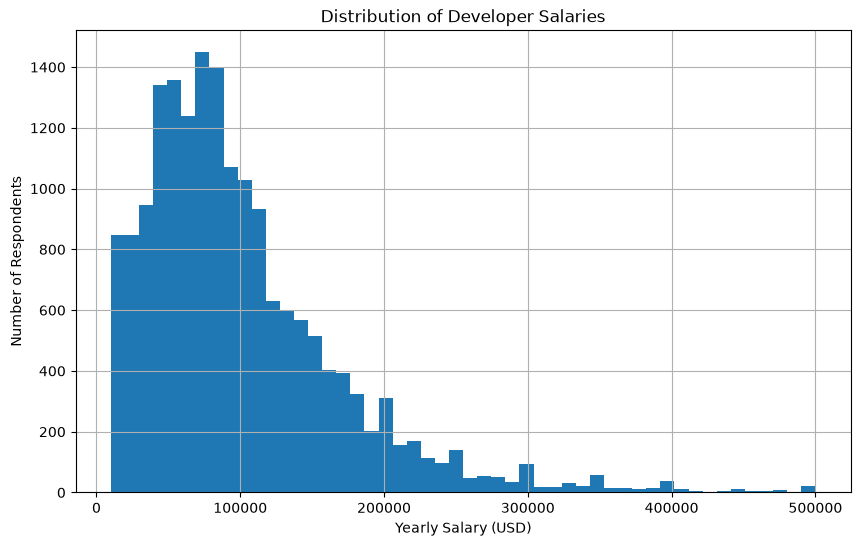

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df_salary_clean["ConvertedCompYearly"].hist(bins=50)
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Developer Salaries")
plt.show()

In [13]:
df_salary_clean[["WorkExp", "ConvertedCompYearly"]].corr()

,WorkExp,ConvertedCompYearly
WorkExp,1.000000,0.324548
ConvertedCompYearly,0.324548,1.000000


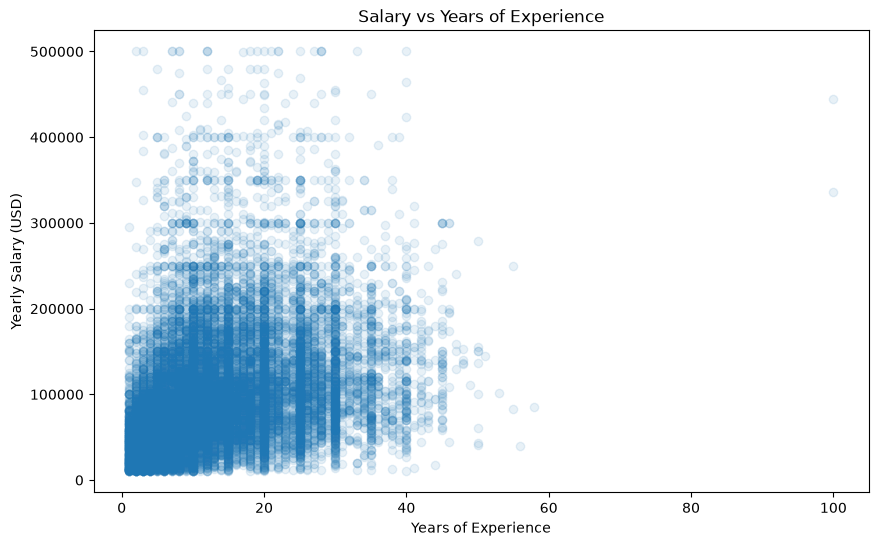

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df_salary_clean["WorkExp"], df_salary_clean["ConvertedCompYearly"], alpha=0.1)
plt.xlabel("Years of Experience")
plt.ylabel("Yearly Salary (USD)")
plt.title("Salary vs Years of Experience")
plt.show()

In [15]:
df_salary_clean["Country"].value_counts().head(20)

Country
United States of America                                4390
Germany                                                 1787
United Kingdom of Great Britain and Northern Ireland    1258
France                                                   806
Canada                                                   742
India                                                    620
Netherlands                                              507
Italy                                                    462
Australia                                                452
Spain                                                    448
Brazil                                                   421
Sweden                                                   385
Poland                                                   356
Switzerland                                              355
Ukraine                                                  346
Austria                                                  235
Czech Republic  

In [16]:
df_salary_clean["Country"].value_counts().head(40)

Country
United States of America                                4390
Germany                                                 1787
United Kingdom of Great Britain and Northern Ireland    1258
France                                                   806
Canada                                                   742
India                                                    620
Netherlands                                              507
Italy                                                    462
Australia                                                452
Spain                                                    448
Brazil                                                   421
Sweden                                                   385
Poland                                                   356
Switzerland                                              355
Ukraine                                                  346
Austria                                                  235
Czech Republic  

In [17]:
country_counts = df_salary_clean["Country"].value_counts()
top_countries = country_counts[country_counts >= 100].index

avg_salary_by_country = df_salary_clean[df_salary_clean["Country"].isin(top_countries)] \
    .groupby("Country")["ConvertedCompYearly"].median() \
    .sort_values(ascending=False)

avg_salary_by_country

Country
United States of America                                150000.0
Switzerland                                             142592.0
Israel                                                  141188.0
Ireland                                                 116015.0
Denmark                                                 101088.0
Australia                                               100765.0
United Kingdom of Great Britain and Northern Ireland     95299.0
Canada                                                   91198.0
Norway                                                   88945.0
Germany                                                  84691.0
New Zealand                                              81318.0
Netherlands                                              81210.0
Austria                                                  79911.0
Finland                                                  79400.5
Sweden                                                   71698.0
Belgium          

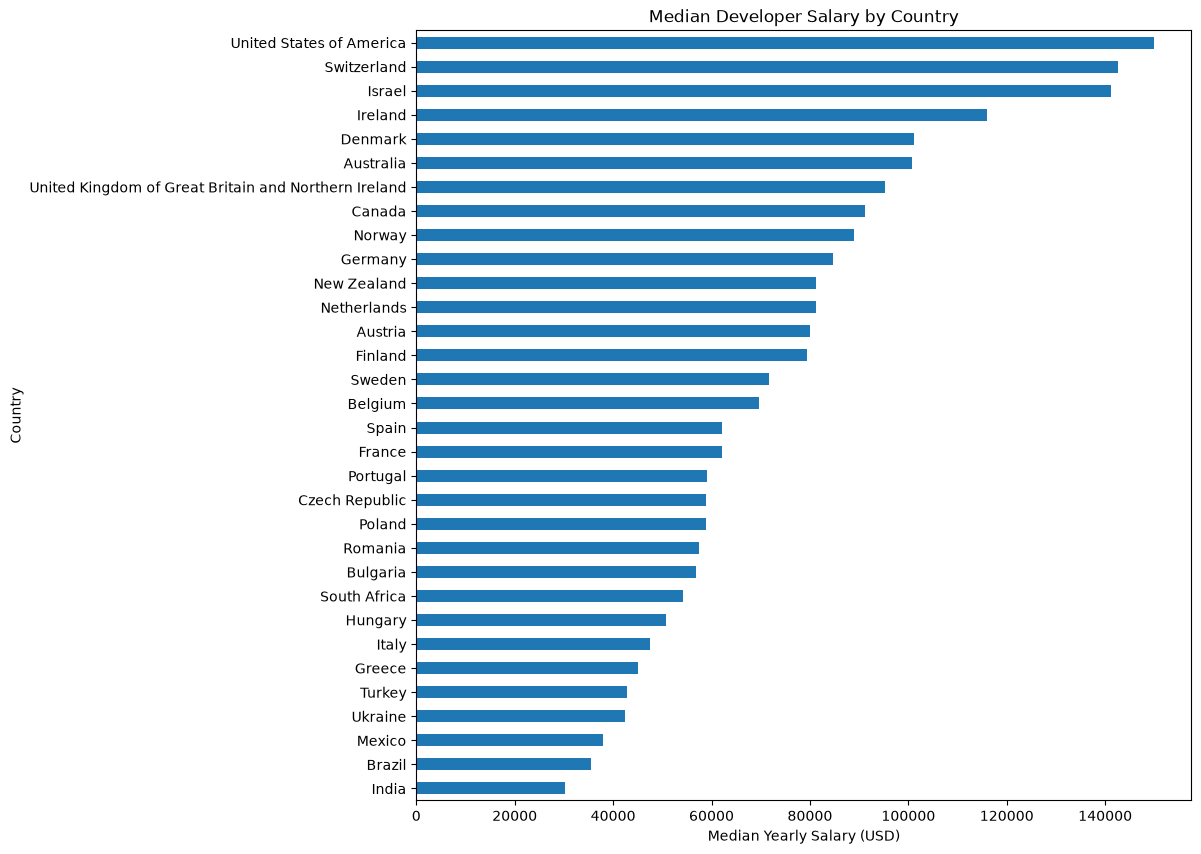

In [18]:
plt.figure(figsize=(10,10))
avg_salary_by_country.sort_values().plot(kind="barh")
plt.xlabel("Median Yearly Salary (USD)")
plt.title("Median Developer Salary by Country")
plt.show()

In [19]:
df_salary_clean["DevType"].value_counts().head(20)

DevType
Developer, full-stack                            5551
Developer, back-end                              3028
Architect, software or solutions                 1264
Developer, desktop or enterprise applications     896
Developer, front-end                              797
Developer, embedded applications or devices       639
Engineering manager                               624
Other (please specify):                           579
DevOps engineer or professional                   577
Developer, mobile                                 519
Data engineer                                     393
Academic researcher                               368
Data scientist                                    273
AI/ML engineer                                    270
Senior executive (C-suite, VP, etc.)              232
Cloud infrastructure engineer                     213
System administrator                              183
Developer, QA or test                             147
Cybersecurity or Inf

In [20]:
# Keep only the columns we'll use for the model
model_data = df_salary_clean[["Country", "WorkExp", "EdLevel", "ConvertedCompYearly"]].dropna()
model_data.shape

(17525, 4)

In [21]:
model_data_encoded = pd.get_dummies(model_data, columns=["Country", "EdLevel"], drop_first=True)
model_data_encoded.shape

(17525, 150)

In [22]:
from sklearn.model_selection import train_test_split

X = model_data_encoded.drop(columns=["ConvertedCompYearly"])
y = model_data_encoded["ConvertedCompYearly"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((14020, 149), (3505, 149))

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](149,)","[ 1560.08,-21992.6 ,-41108.29,..., 23972.73, 1668.79, 8924.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](149,)","['WorkExp','Country_Albania','Country_Algeria',..., 'EdLevel_Professional degree (JD, MD, Ph.D, Ed.D, etc.)', 'EdLevel_Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)', 'EdLevel_Some college/university study without earning a degree']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.024e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,149
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(145)


In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $33,781
R² Score: 0.433


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest - Mean Absolute Error: ${rf_mae:,.0f}")
print(f"Random Forest - R² Score: {rf_r2:.3f}")

Random Forest - Mean Absolute Error: $34,059
Random Forest - R² Score: 0.416


In [27]:
import json

coefficients = dict(zip(X_train.columns, model.coef_))
intercept = model.intercept_

output = {
    "intercept": intercept,
    "coefficients": coefficients
}

with open("model_coefficients.json", "w") as f:
    json.dump(output, f, indent=2)

print("Saved! Intercept:", intercept)
print("Number of coefficients:", len(coefficients))

Saved! Intercept: 30243.559795962457
Number of coefficients: 149
